use unsupervised clustering for diff cluster


=== Processing Participant Cluster 0 ===
No data for this cluster, skipping...

=== Processing Participant Cluster 1 ===


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette Score: 0.778
Adjusted Rand Index: 0.754
Normalized Mutual Information: 0.635


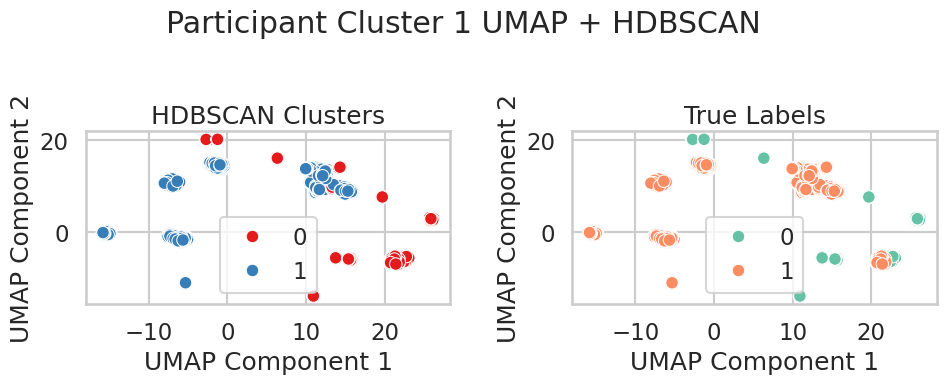


=== Processing Participant Cluster 2 ===


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette Score: 0.691
Adjusted Rand Index: 0.923
Normalized Mutual Information: 0.850


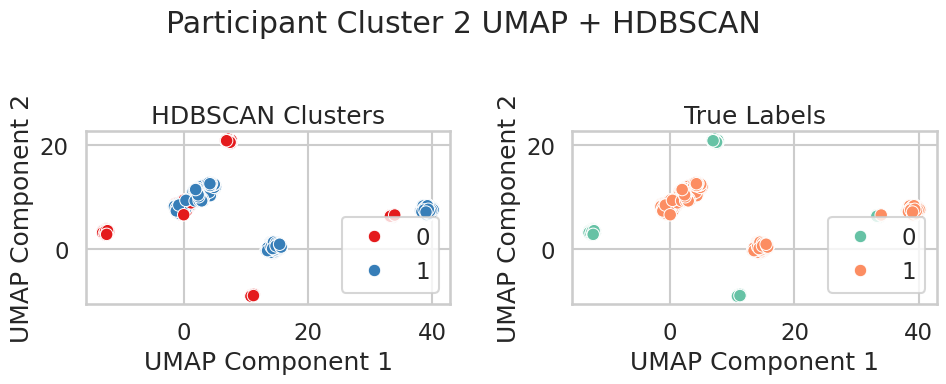


=== Processing Participant Cluster 3 ===


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette Score: 0.815
Adjusted Rand Index: 0.781
Normalized Mutual Information: 0.643


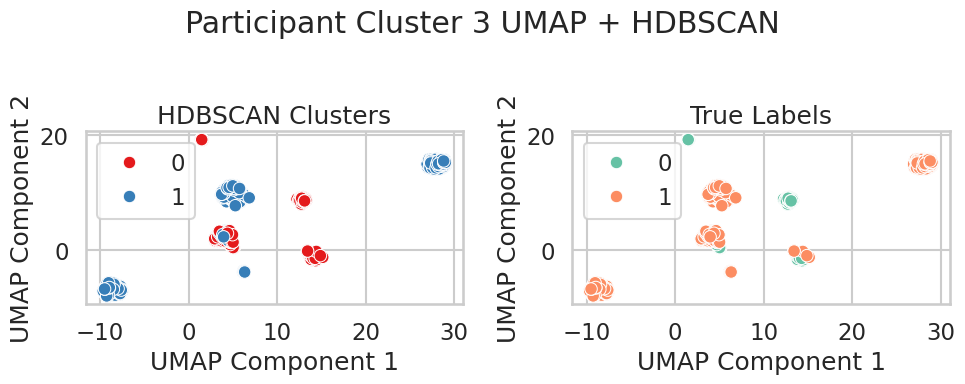


=== Processing Participant Cluster 4 ===


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette Score: 0.628
Adjusted Rand Index: 0.522
Normalized Mutual Information: 0.411


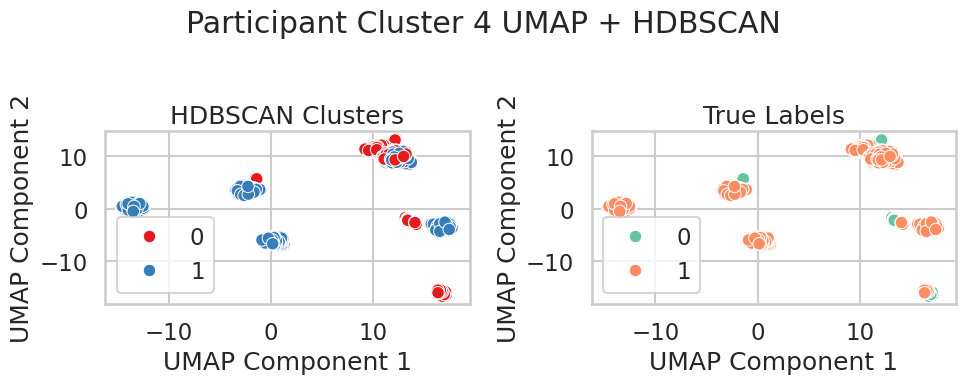


=== Processing Participant Cluster 5 ===


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette Score: 0.920
Adjusted Rand Index: 0.605
Normalized Mutual Information: 0.500


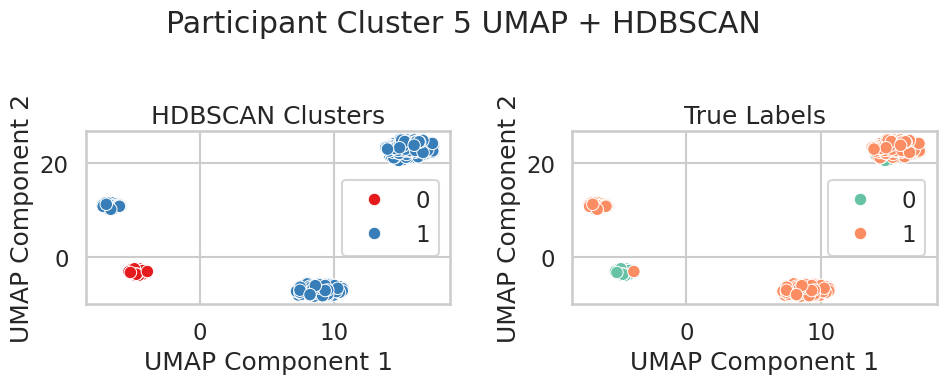


=== Processing Participant Cluster 6 ===


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette Score: 0.784
Adjusted Rand Index: 0.873
Normalized Mutual Information: 0.797


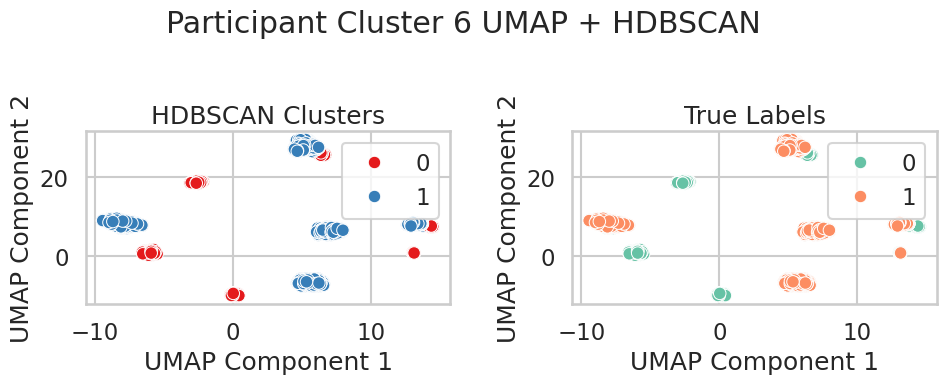

In [ ]:
import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

sns.set(style='whitegrid', context='talk')

# ====== Loop over participant clusters ======
for cluster_i, cluster_ids in enumerate(participant_clusters):
    print(f"\n=== Processing Participant Cluster {cluster_i} ===")

    # Select data for participants in this cluster
    mask = np.isin(participant_ids, cluster_ids)
    X_cluster = X[mask]
    y_cluster = y[mask]

    if len(X_cluster) == 0:
        print("No data for this cluster, skipping...")
        continue

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

    # UMAP projection
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)

    # HDBSCAN clustering
    clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
    cluster_labels = clusterer.fit_predict(X_umap)

    # Map clusters to majority true label
    mapped_labels = np.zeros_like(cluster_labels)
    for c in np.unique(cluster_labels):
        if c == -1:  # noise points
            continue
        mask_c = (cluster_labels == c)
        majority_label = Counter(y_cluster[mask_c]).most_common(1)[0][0]
        mapped_labels[mask_c] = majority_label

    # Evaluate clustering
    sil = silhouette_score(X_umap, cluster_labels) if len(np.unique(cluster_labels)) > 1 else np.nan
    ari = adjusted_rand_score(y_cluster, mapped_labels)
    nmi = normalized_mutual_info_score(y_cluster, mapped_labels)

    print(f"Silhouette Score: {sil:.3f}")
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"Normalized Mutual Information: {nmi:.3f}")

    # Plot clusters vs true labels
    plt.figure(figsize=(10, 4))
    plt.suptitle(f"Participant Cluster {cluster_i} UMAP + HDBSCAN")

    plt.subplot(1, 2, 1)
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=mapped_labels, palette='Set1', legend='full')
    plt.title('HDBSCAN Clusters')
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_cluster, palette='Set2', legend='full')
    plt.title('True Labels')
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
